In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

(trainX, _), (testX, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [2]:
trainX = trainX.astype('float32') / 255.
testX = testX.astype('float32') / 255.

trainX = trainX.reshape(-1, 28, 28, 1)
testX = testX.reshape(-1, 28, 28, 1)

In [3]:
# Add Gaussian Noise
noise_factor = 0.3

train_noisy = trainX + noise_factor * np.random.normal(size=trainX.shape)
test_noisy = testX + noise_factor * np.random.normal(size=testX.shape)

train_noisy = np.clip(train_noisy, 0., 1.)
test_noisy = np.clip(test_noisy, 0., 1.)

input_img = Input(shape=(28,28,1))

In [4]:
# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [5]:
# Training
autoencoder.fit(
    train_noisy, trainX,
    epochs=5,
    batch_size=128,
    validation_data=(test_noisy, testX)
)
decoded_imgs = autoencoder.predict(test_noisy)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.2110 - val_loss: 0.0902
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0885 - val_loss: 0.0847
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0845 - val_loss: 0.0819
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0822 - val_loss: 0.0806
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0807 - val_loss: 0.0795
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


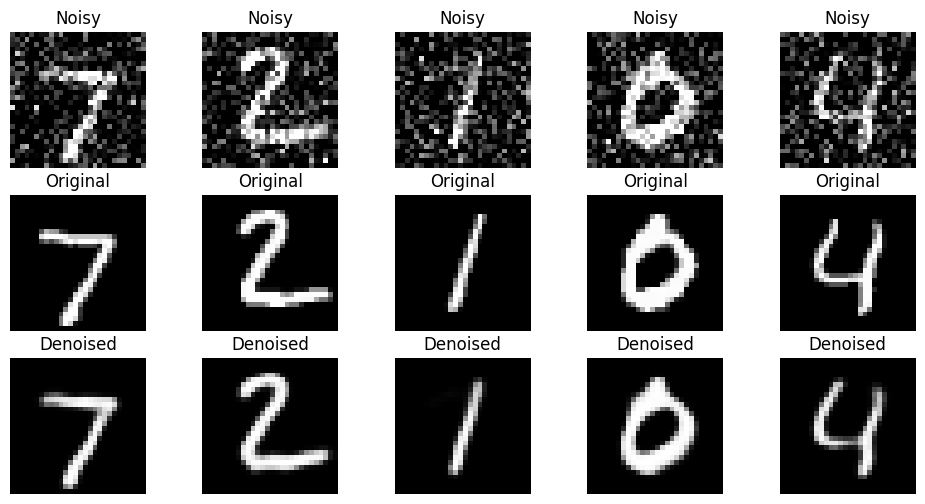

In [6]:
n = 5
plt.figure(figsize=(12,6))

for i in range(n):

    ax = plt.subplot(3, n, i+1)
    plt.imshow(test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    ax = plt.subplot(3, n, i+n+1)
    plt.imshow(testX[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    ax = plt.subplot(3, n, i+2*n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.show()